In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization

In [2]:
df = pd.read_csv("/content/high_popularity_spotify_data.csv")
df

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.1220,0.535,"Lady Gaga, Bruno Mars",3,0.0304,...,0.000000,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.1170,0.438,Billie Eilish,4,0.0358,...,0.060800,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.1590,0.372,Gracie Abrams,4,0.0368,...,0.000000,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
3,0.910,112.966,0.670,pop,-4.070,0.3040,0.786,Sabrina Carpenter,4,0.0634,...,0.000000,4B4Elma4nNDUyl6D5PvQkj,0,0,157280,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
4,0.783,149.027,0.777,pop,-4.477,0.3550,0.939,"ROSÉ, Bruno Mars",4,0.2600,...,0.000000,2IYQwwgxgOIn7t3iF6ufFD,0,0,169917,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,0.422,124.357,0.573,latin,-7.621,0.1020,0.693,Libianca,5,0.0678,...,0.000013,5Hmh6N8oisrcuZKa8EY5dn,0,10,184791,0.5510,26b3oVLrRUaaybJulow9kz,afro-latin,audio_features,0oU30cCr8klmMsuOKHDLkh
1682,0.725,105.016,0.711,latin,-8.315,0.1100,0.530,Omah Lay,4,0.0941,...,0.129000,5NLjxx8nRy9ooUmgpOvfem,0,3,183057,0.4240,1wADwLSkYhrSmy4vdy6BRn,afro-latin,audio_features,0oU30cCr8klmMsuOKHDLkh
1683,0.809,99.005,0.724,latin,-5.022,0.0765,0.606,"Davido, FAVE",4,0.0929,...,0.000000,6lI21W76LD0S3vC55GrfSS,0,6,194040,0.1820,7vKXc90NT5WBm3UTT4iTVG,afro-latin,audio_features,0oU30cCr8klmMsuOKHDLkh
1684,0.642,83.389,0.463,latin,-4.474,0.0686,0.339,"Future, Drake, Tems",4,0.3400,...,0.000000,6tE9Dnp2zInFij4jKssysL,1,1,189893,0.3140,59nOXPmaKlBfGMDeOVGrIK,afro-latin,audio_features,0oU30cCr8klmMsuOKHDLkh


In [3]:
df["playlist_genre"].unique()

array(['pop', 'rock', 'jazz', 'classical', 'hip-hop', 'afrobeats',
       'latin', 'indian', 'country', 'r&b', 'electronic', 'soul',
       'gaming', 'j-pop', 'metal', 'reggae', 'k-pop', 'arabic', 'punk',
       'blues', 'folk', 'lofi', 'brazilian', 'turkish', 'ambient',
       'korean', 'world', 'indie'], dtype=object)

In [4]:
df["playlist_genre"].nunique()

28

In [5]:
df.drop(["type", "playlist_subgenre", "track_album_name", "uri", "track_href", "track_artist", "track_album_id", "id", "playlist_id", "track_id", "track_name", "playlist_name", "analysis_url", "track_album_release_date"], axis = 1, inplace = True)

In [6]:
df

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,time_signature,speechiness,track_popularity,instrumentalness,mode,key,duration_ms,acousticness
0,0.592,157.969,0.521,pop,-7.777,0.1220,0.535,3,0.0304,100,0.000000,0,6,251668,0.3080
1,0.507,104.978,0.747,pop,-10.171,0.1170,0.438,4,0.0358,97,0.060800,1,2,210373,0.2000
2,0.808,108.548,0.554,pop,-4.169,0.1590,0.372,4,0.0368,93,0.000000,1,1,166300,0.2140
3,0.910,112.966,0.670,pop,-4.070,0.3040,0.786,4,0.0634,81,0.000000,0,0,157280,0.0939
4,0.783,149.027,0.777,pop,-4.477,0.3550,0.939,4,0.2600,98,0.000000,0,0,169917,0.0283
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,0.422,124.357,0.573,latin,-7.621,0.1020,0.693,5,0.0678,76,0.000013,0,10,184791,0.5510
1682,0.725,105.016,0.711,latin,-8.315,0.1100,0.530,4,0.0941,74,0.129000,0,3,183057,0.4240
1683,0.809,99.005,0.724,latin,-5.022,0.0765,0.606,4,0.0929,69,0.000000,0,6,194040,0.1820
1684,0.642,83.389,0.463,latin,-4.474,0.0686,0.339,4,0.3400,82,0.000000,1,1,189893,0.3140


In [7]:
df["playlist_genre"] = df["playlist_genre"].replace({'pop': 1, 'rock': 2, 'jazz': 3, 'classical': 4, 'hip-hop': 5, 'afrobeats': 6, 'latin': 7, 'indian': 8, 'country': 9, 'r&b': 10, 'electronic': 11, 'soul': 12, 'gaming': 13, 'j-pop': 14, 'metal': 15, 'reggae': 16, 'k-pop': 17, 'arabic': 18, 'punk': 19, 'blues': 20, 'folk': 21, 'lofi': 22, 'brazilian': 23, 'turkish': 24, 'ambient': 25, 'korean': 26, 'world': 27, 'indie': 28})
df["playlist_genre"] = df["playlist_genre"] - 1

<ipython-input-7-de2246f4defc>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["playlist_genre"] = df["playlist_genre"].replace({'pop': 1, 'rock': 2, 'jazz': 3, 'classical': 4, 'hip-hop': 5, 'afrobeats': 6, 'latin': 7, 'indian': 8, 'country': 9, 'r&b': 10, 'electronic': 11, 'soul': 12, 'gaming': 13, 'j-pop': 14, 'metal': 15, 'reggae': 16, 'k-pop': 17, 'arabic': 18, 'punk': 19, 'blues': 20, 'folk': 21, 'lofi': 22, 'brazilian': 23, 'turkish': 24, 'ambient': 25, 'korean': 26, 'world': 27, 'indie': 28})


In [8]:
df

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,time_signature,speechiness,track_popularity,instrumentalness,mode,key,duration_ms,acousticness
0,0.592,157.969,0.521,0,-7.777,0.1220,0.535,3,0.0304,100,0.000000,0,6,251668,0.3080
1,0.507,104.978,0.747,0,-10.171,0.1170,0.438,4,0.0358,97,0.060800,1,2,210373,0.2000
2,0.808,108.548,0.554,0,-4.169,0.1590,0.372,4,0.0368,93,0.000000,1,1,166300,0.2140
3,0.910,112.966,0.670,0,-4.070,0.3040,0.786,4,0.0634,81,0.000000,0,0,157280,0.0939
4,0.783,149.027,0.777,0,-4.477,0.3550,0.939,4,0.2600,98,0.000000,0,0,169917,0.0283
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,0.422,124.357,0.573,6,-7.621,0.1020,0.693,5,0.0678,76,0.000013,0,10,184791,0.5510
1682,0.725,105.016,0.711,6,-8.315,0.1100,0.530,4,0.0941,74,0.129000,0,3,183057,0.4240
1683,0.809,99.005,0.724,6,-5.022,0.0765,0.606,4,0.0929,69,0.000000,0,6,194040,0.1820
1684,0.642,83.389,0.463,6,-4.474,0.0686,0.339,4,0.3400,82,0.000000,1,1,189893,0.3140


In [9]:
x = df.drop("playlist_genre", axis = 1)
y = df["playlist_genre"].values

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [11]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [12]:
model = Sequential()
model.add(Dense(128, activation="relu", kernel_initializer="random_uniform", input_shape=x_train.shape[1:], kernel_regularizer = tensorflow.keras.regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(64, activation="relu", kernel_initializer="random_uniform", kernel_regularizer = tensorflow.keras.regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(32, activation="relu", kernel_initializer="random_uniform", kernel_regularizer = tensorflow.keras.regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(28, activation="sigmoid"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           1,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 28)                  │             924 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,076 (54.98 KB)

 Trainable params: 13,628 (53.23 KB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
callback = EarlyStopping(monitor = "val_loss", patience = 20, min_delta = 0.001, verbose = 1, restore_best_weights=True)

In [15]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [16]:
history = model.fit(x_train, y_train, epochs = 3000, batch_size = 32, validation_data = (x_test, y_test), callbacks=[callback], verbose = 1)

Epoch 1/3000
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.1038 - loss: 3.5464 - val_accuracy: 0.1479 - val_loss: 3.3577
Epoch 2/3000
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3089 - loss: 2.7520 - val_accuracy: 0.2160 - val_loss: 3.2684
Epoch 3/3000
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3772 - loss: 2.4835 - val_accuracy: 0.2663 - val_loss: 3.1531
Epoch 4/3000
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4009 - loss: 2.3063 - val_accuracy: 0.3107 - val_loss: 3.0262
Epoch 5/3000
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4197 - loss: 2.2289 - val_accuracy: 0.3225 - val_loss: 2.8212
Epoch 6/3000
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4306 - loss: 2.1253 - val_accuracy: 0.3195 - val_loss: 2.6502
Epoch 7/3000
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4146 - loss: 2.1708 - val_accuracy: 0.3373 - val_loss: 2.4916
Epoch 8/3000
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4218 - loss: 2.0393 - val_accuracy: 0

Text(0.5, 0, 'Epoch')

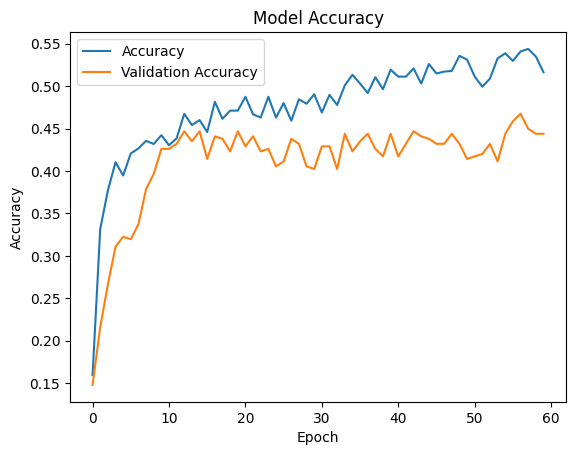

In [17]:
plt.plot(history.history['accuracy'], label = "Accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation Accuracy")
plt.legend()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

Text(0.5, 0, 'Epoch')

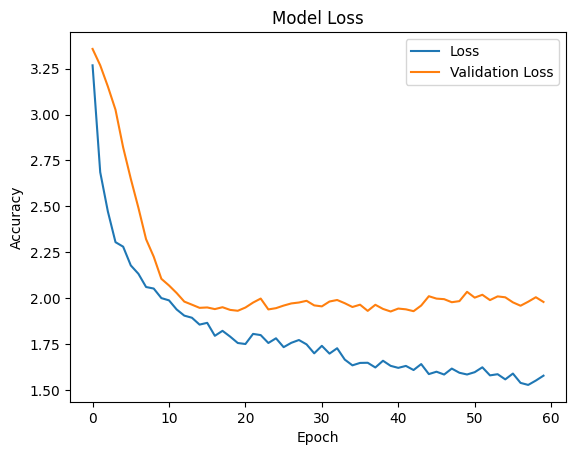

In [18]:
plt.plot(history.history['loss'], label = "Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")

plt.legend()
plt.title('Model Loss')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')